<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/TradingStrategies/TradingStrategies/Momentum_Strategy_(Time_Series_%2B_Cross_Sectional).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dual-Momentum Sector Rotation System

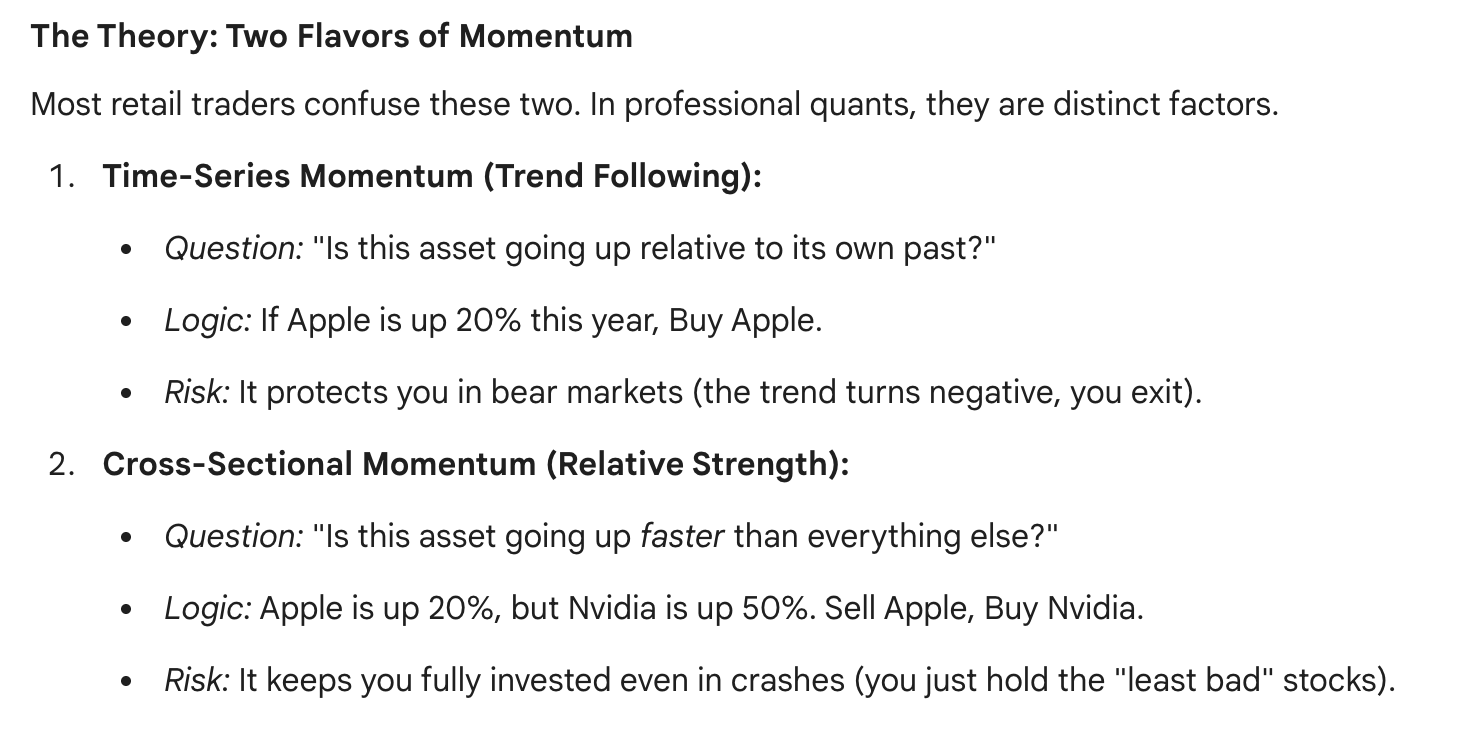

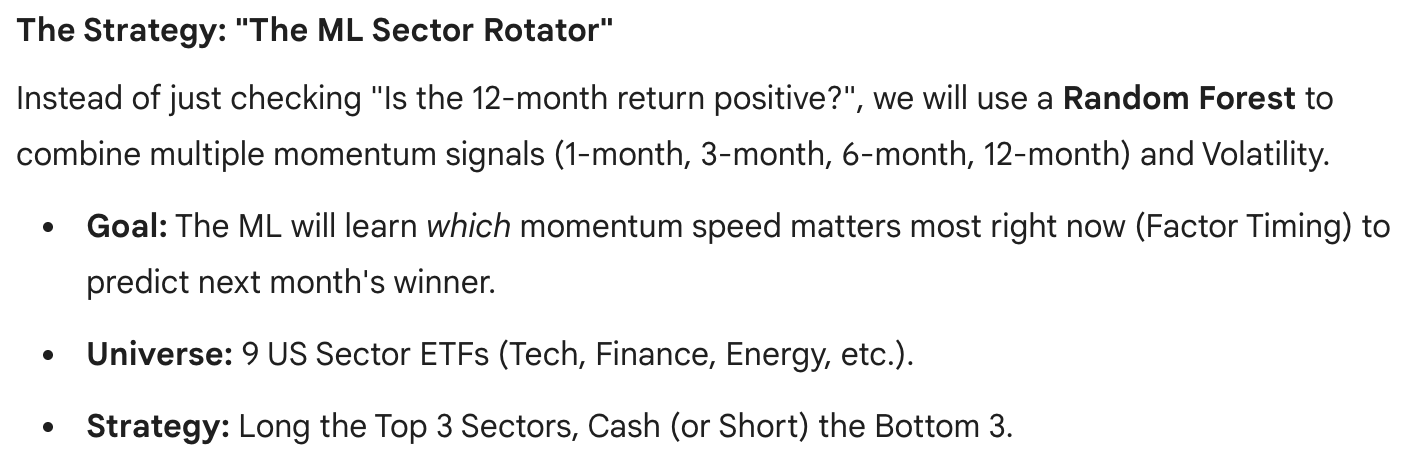

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
# --- CONFIGURATION ---
tickers = [
    'XLK', # Technology
    'XLF', # Financials
    'XLE', # Energy
    'XLV', # Health Care
    'XLY', # Consumer Discretionary
    'XLP', # Consumer Staples
    'XLI', # Industrials
    'XLU', # Utilities
    'XLB'  # Materials
]

In [4]:
print("📥 Downloading Sector Data...")
data = yf.download(tickers, start='2010-01-01', end='2024-01-01', progress=False, auto_adjust=False)['Adj Close']

# Resample to Monthly data (Momentum is usually a low-frequency signal)
# We take the last price of each month
monthly_prices = data.resample('M').last()

print(f"✅ Data Ready. Shape: {monthly_prices.shape} (Months, Tickers)")
monthly_prices.head()

📥 Downloading Sector Data...
✅ Data Ready. Shape: (168, 9) (Months, Tickers)


/tmp/ipython-input-768167110.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = data.resample('M').last()


Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,
2010-01-31,10.693367,16.107286,8.676300,20.285156,8.458260,17.042145,8.501962,23.832022,11.885234
2010-02-28,11.175882,16.591988,8.982236,21.366835,8.752846,17.582041,8.389677,23.923445,12.547123
2010-03-31,12.060583,17.059362,9.781557,23.224247,9.351523,18.244431,8.615406,24.561581,13.526655
2010-04-30,12.085474,17.768194,9.910342,24.212988,9.468922,18.048466,8.841977,23.606026,14.342210
2010-05-31,10.933461,15.733643,9.002710,22.005037,8.760474,17.212343,8.353983,22.069494,13.333066


In [7]:
# --- FACTOR CALCULATION ---

# We will stack the data so it's in "Long Format" (Date, Ticker, Features...)
# This is required for ML models (Panel Data)

df_stacked = monthly_prices.stack().reset_index()
df_stacked.columns = ['Date', 'Ticker', 'Price']
df_stacked.set_index('Date', inplace=True)
df_stacked.head()

,Ticker,Price
Date,,
2010-01-31,XLB,10.693367
2010-01-31,XLE,16.107286
2010-01-31,XLF,8.676300
2010-01-31,XLI,20.285156
2010-01-31,XLK,8.458260


In [8]:
# Function to calculate rolling features per ticker
def calculate_factors(x):
    # 1. Momentum Factors (Returns)
    x['Mom_1M'] = x['Price'].pct_change(1)
    x['Mom_3M'] = x['Price'].pct_change(3)
    x['Mom_6M'] = x['Price'].pct_change(6)
    x['Mom_12M'] = x['Price'].pct_change(12)

    # 2. Risk Factors (Volatility)
    # Standard deviation of the last 12 months of returns
    x['Vol_12M'] = x['Mom_1M'].rolling(12).std()

    # 3. TARGET: Next Month's Return
    x['Target_Next_M'] = x['Price'].shift(-1) / x['Price'] - 1

    return x

In [9]:
# Apply to each ticker group
print("⚙️ Engineering Factors...")
df_factors = df_stacked.groupby('Ticker', group_keys=False).apply(calculate_factors)

# Drop NaN values (first 12 months are empty)
df_factors.dropna(inplace=True)

df_factors.head()

⚙️ Engineering Factors...


/tmp/ipython-input-3508811047.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_factors = df_stacked.groupby('Ticker', group_keys=False).apply(calculate_factors)


,Ticker,Price,Mom_1M,Mom_3M,Mom_6M,Mom_12M,Vol_12M,Target_Next_M
Date,,,,,,,,
2011-01-31,XLB,14.121399,0.000781,0.113578,0.235277,0.320576,0.068951,0.026535
2011-01-31,XLE,21.991430,0.071795,0.240300,0.370973,0.365309,0.067590,0.073684
2011-01-31,XLF,10.137938,0.028213,0.130458,0.121445,0.168463,0.063875,0.027439
2011-01-31,XLI,27.350851,0.039289,0.131919,0.208676,0.348318,0.069625,0.021247
2011-01-31,XLK,10.634962,0.031759,0.071189,0.194239,0.257346,0.059794,0.021931


In [10]:
# --- EXPANDING WINDOW TRAINING ---

unique_dates = df_factors.index.unique().sort_values()
train_start_index = 60 # Start training after 5 years (60 months) of data

predictions = []

print("🧠 Training & Predicting (Expanding Window)...")

# Iterate through time, month by month
for i in range(train_start_index, len(unique_dates) - 1):

    # 1. Define Window
    train_date = unique_dates[i] # Train up to this date
    predict_date = unique_dates[i+1] # Predict for this date

    # 2. Slice Data
    # Train set: All data before the split date
    train_data = df_factors[df_factors.index <= train_date]
    # Test set: Only the single month we are predicting
    test_data = df_factors[df_factors.index == predict_date]

    feature_cols = ['Mom_1M', 'Mom_3M', 'Mom_6M', 'Mom_12M', 'Vol_12M']
    X_train = train_data[feature_cols]
    y_train = train_data['Target_Next_M']
    X_test = test_data[feature_cols]

    # 3. Train Model (Re-trained every month! Simple model keeps it fast)
    model = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # 4. Predict
    preds = model.predict(X_test)

    # 5. Store Results
    # We create a dataframe for this month's predictions
    month_preds = pd.DataFrame({
        'Date': predict_date,
        'Ticker': test_data['Ticker'],
        'Pred_Return': preds,
        'Actual_Return': test_data['Target_Next_M']
    })
    predictions.append(month_preds)

# Combine all monthly predictions
all_preds = pd.concat(predictions)
print("✅ Walk-Forward Predictions Complete.")

🧠 Training & Predicting (Expanding Window)...
✅ Walk-Forward Predictions Complete.


In [11]:
# --- STRATEGY CONSTRUCTION ---

def simulate_strategy(df_pred):
    # Sort by Prediction for each date
    df_sorted = df_pred.sort_values(by=['Date', 'Pred_Return'], ascending=[True, False])

    # Select Top 3 Winners per month
    top_3 = df_sorted.groupby('Date').head(3)

    # Calculate Portfolio Return (Mean of Top 3)
    # Assuming Equal Weight allocation
    portfolio_ret = top_3.groupby('Date')['Actual_Return'].mean()

    return portfolio_ret

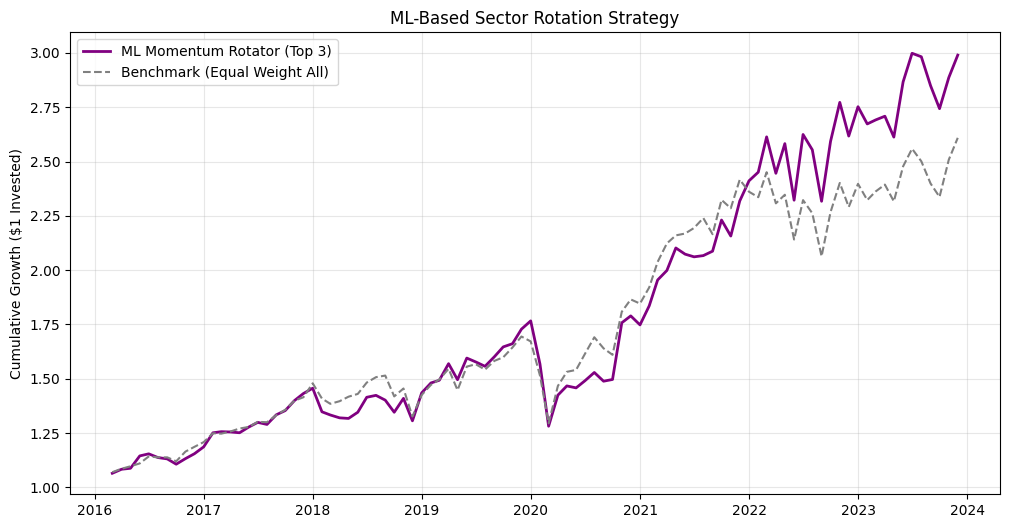

In [16]:
# 1. ML Strategy Returns
all_preds.index.name = 'date_index'
strategy_ret = simulate_strategy(all_preds)

# 2. Benchmark: "Equal Weight Universe" (Buy all 9 sectors)
benchmark_ret = all_preds.groupby('Date')['Actual_Return'].mean()

# --- CUMULATIVE RETURNS PLOT ---
# Convert to Equity Curve
strat_eq = (1 + strategy_ret).cumprod()
bench_eq = (1 + benchmark_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(strat_eq, label='ML Momentum Rotator (Top 3)', color='purple', linewidth=2)
plt.plot(bench_eq, label='Benchmark (Equal Weight All)', color='gray', linestyle='--')
plt.title("ML-Based Sector Rotation Strategy")
plt.ylabel("Cumulative Growth ($1 Invested)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# --- METRICS TABLE (REUSED) ---

def calculate_metrics_monthly(equity_curve):
    # Monthly returns are already calculated, just get stats
    rets = equity_curve.pct_change().dropna()

    # Annualized stats (multiply by 12 for months)
    sharpe = rets.mean() / rets.std() * np.sqrt(12)

    # Drawdown
    rolling_max = equity_curve.cummax()
    dd = (equity_curve / rolling_max) - 1
    max_dd = dd.min()

    total_ret = equity_curve.iloc[-1] - 1

    return sharpe, max_dd, total_ret

      Strategy Total Return Sharpe Ratio Max Drawdown
0    Benchmark      160.91%         0.81      -23.60%
1  ML Momentum      199.00%         0.83      -27.46%


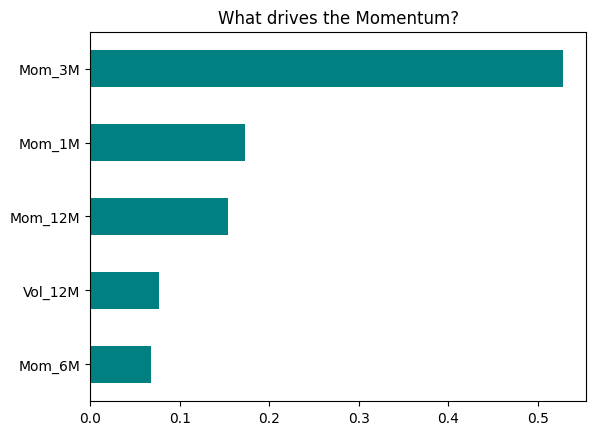

In [18]:
metrics = []
for name, curve in {'Benchmark': bench_eq, 'ML Momentum': strat_eq}.items():
    s, d, t = calculate_metrics_monthly(curve)
    metrics.append({
        "Strategy": name,
        "Total Return": f"{t*100:.2f}%",
        "Sharpe Ratio": f"{s:.2f}",
        "Max Drawdown": f"{d*100:.2f}%"
    })

print(pd.DataFrame(metrics))

# --- FEATURE IMPORTANCE ---
# What did the AI care about? (Using the last trained model)
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', color='teal', title='What drives the Momentum?')
plt.show()

In [19]:
# --- 1. CONSTRUCT NAIVE STRATEGY (Simple 12M Momentum) ---

def simulate_naive_momentum(df_factors):
    # We use the same 'df_factors' dataframe
    # Strategy: Sort by 'Mom_12M' (Raw past performance), Select Top 3

    # We need to act on the same dates as the ML model for fair comparison
    test_dates = all_preds['Date'].unique()

    naive_returns = []

    for date in test_dates:
        # Get data for this month
        current_data = df_factors[df_factors.index == date]

        # Sort by 12-Month Return (Simple Momentum)
        top_3_naive = current_data.sort_values(by='Mom_12M', ascending=False).head(3)

        # Calculate return (Equal weight of winners)
        # Note: We use 'Target_Next_M' to see how they performed in the *next* month
        monthly_ret = top_3_naive['Target_Next_M'].mean()

        naive_returns.append({'Date': date, 'Naive_Return': monthly_ret})

    return pd.DataFrame(naive_returns).set_index('Date')

In [20]:
# Run Simulation
naive_results = simulate_naive_momentum(df_factors)
naive_eq = (1 + naive_results['Naive_Return']).cumprod()

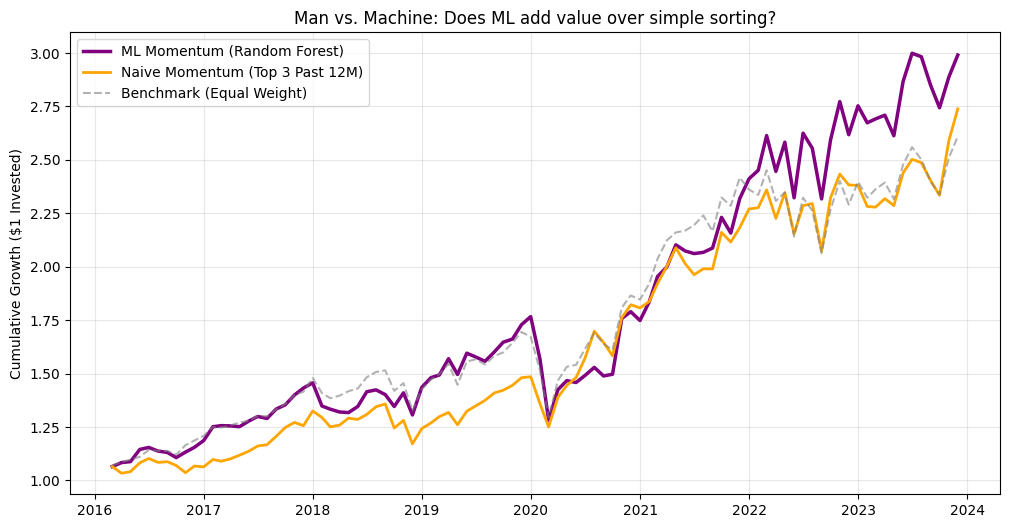

In [21]:
# --- 2. PLOT COMPARISON ---
plt.figure(figsize=(12, 6))

# Plot ML Strategy
plt.plot(strat_eq, label='ML Momentum (Random Forest)', color='purple', linewidth=2.5)

# Plot Naive Strategy
plt.plot(naive_eq, label='Naive Momentum (Top 3 Past 12M)', color='orange', linewidth=2, linestyle='-')

# Plot Benchmark
plt.plot(bench_eq, label='Benchmark (Equal Weight)', color='gray', linestyle='--', alpha=0.6)

plt.title("Man vs. Machine: Does ML add value over simple sorting?")
plt.ylabel("Cumulative Growth ($1 Invested)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# --- 3. METRICS UPDATE ---
metrics_updated = []
strategies = {
    'Benchmark': bench_eq,
    'Naive Momentum': naive_eq,
    'ML Momentum': strat_eq
}

for name, curve in strategies.items():
    s, d, t = calculate_metrics_monthly(curve)
    metrics_updated.append({
        "Strategy": name,
        "Total Return": f"{t*100:.2f}%",
        "Sharpe Ratio": f"{s:.2f}",
        "Max Drawdown": f"{d*100:.2f}%"
    })

print("\n🏆 Final Performance Report (Updated):")
print(pd.DataFrame(metrics_updated))


🏆 Final Performance Report (Updated):
         Strategy Total Return Sharpe Ratio Max Drawdown
0       Benchmark      160.91%         0.81      -23.60%
1  Naive Momentum      173.84%         0.89      -15.81%
2     ML Momentum      199.00%         0.83      -27.46%


📊 ALPHA METRICS REPORT
-----------------------
Alpha (Annualized): 1.36%  <-- Pure 'Skill'
Beta:               1.06      <-- Market Sensitivity
Information Ratio:  0.31      <-- Consistency (Goal > 0.5)
R-Squared:          0.86      <-- How much is just 'The Market'?


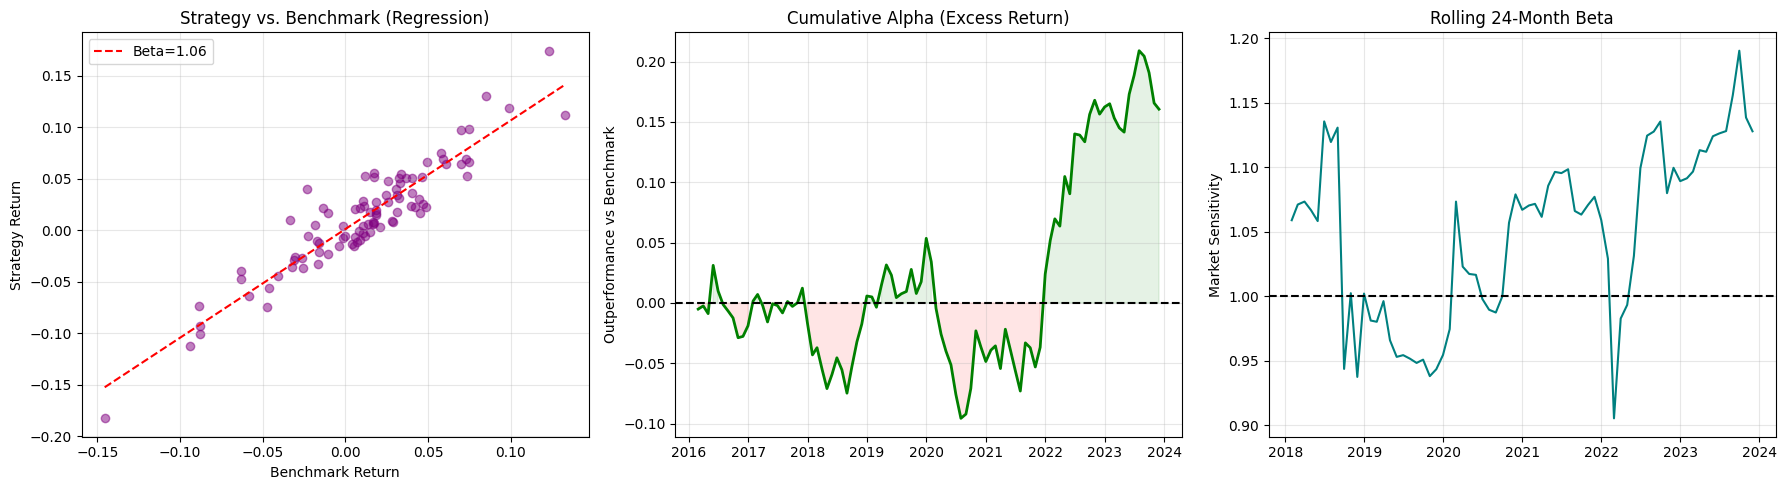

In [23]:
from scipy import stats

# --- 1. METRICS CALCULATION ---
# Ensure alignment (though they should be aligned already)
audit_df = pd.DataFrame({
    'Strat': strategy_ret,
    'Bench': benchmark_ret
}).dropna()

# A. Linear Regression (CAPM Style)
slope, intercept, r_value, p_value, std_err = stats.linregress(audit_df['Bench'], audit_df['Strat'])

beta = slope
alpha_annualized = intercept * 12  # Monthly data -> Annualize
r_squared = r_value ** 2

# B. Information Ratio (Return per unit of Active Risk)
active_ret = audit_df['Strat'] - audit_df['Bench']
tracking_error = active_ret.std() * np.sqrt(12)
info_ratio = (active_ret.mean() * 12) / tracking_error

print("📊 ALPHA METRICS REPORT")
print(f"-----------------------")
print(f"Alpha (Annualized): {alpha_annualized*100:.2f}%  <-- Pure 'Skill'")
print(f"Beta:               {beta:.2f}      <-- Market Sensitivity")
print(f"Information Ratio:  {info_ratio:.2f}      <-- Consistency (Goal > 0.5)")
print(f"R-Squared:          {r_squared:.2f}      <-- How much is just 'The Market'?")

# --- 2. VISUALIZATIONS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: The Scatter (Beta)
# If points are above the red line, that's positive alpha.
axes[0].scatter(audit_df['Bench'], audit_df['Strat'], alpha=0.5, color='purple')
x_range = np.linspace(audit_df['Bench'].min(), audit_df['Bench'].max(), 100)
axes[0].plot(x_range, intercept + slope * x_range, 'r--', label=f'Beta={beta:.2f}')
axes[0].set_title('Strategy vs. Benchmark (Regression)')
axes[0].set_xlabel('Benchmark Return')
axes[0].set_ylabel('Strategy Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot B: Cumulative Alpha (The "Value Add" Curve)
# This shows PURE excess return over time.
cum_excess = (1 + active_ret).cumprod() - 1
axes[1].plot(cum_excess, color='green', linewidth=2)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Cumulative Alpha (Excess Return)')
axes[1].set_ylabel('Outperformance vs Benchmark')
axes[1].fill_between(cum_excess.index, cum_excess, 0, where=(cum_excess>0), color='green', alpha=0.1)
axes[1].fill_between(cum_excess.index, cum_excess, 0, where=(cum_excess<0), color='red', alpha=0.1)
axes[1].grid(True, alpha=0.3)

# Plot C: Rolling Beta (Regime Change)
# Did we become riskier in crashes?
rolling_beta = audit_df['Strat'].rolling(24).cov(audit_df['Bench']) / audit_df['Bench'].rolling(24).var()
axes[2].plot(rolling_beta, color='teal')
axes[2].axhline(1.0, color='black', linestyle='--')
axes[2].set_title('Rolling 24-Month Beta')
axes[2].set_ylabel('Market Sensitivity')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()